In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('./data/car_miles_per_gallon.csv')

In [3]:
df.head()

,Name,Year,Origin,Cylinders,Displacement,Horsepower,Weight,Acceleration,MPG
0,Chevrolet Chevelle Malibu,2015,1,8,307.0,130.0,3504,12.0,8.0
1,Buick Skylark 320,2015,1,8,350.0,165.0,3693,11.5,15.0
2,Plymouth Satellite,2015,1,8,318.0,150.0,3436,11.0,18.0
3,Amc Rebel Sst,2015,1,8,304.0,150.0,3433,12.0,16.0
4,Ford Torino,2015,1,8,302.0,140.0,3449,10.5,17.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Name          398 non-null    object 
 1   Year          398 non-null    int64  
 2   Origin        398 non-null    int64  
 3   Cylinders     398 non-null    int64  
 4   Displacement  398 non-null    float64
 5   Horsepower    392 non-null    float64
 6   Weight        398 non-null    int64  
 7   Acceleration  398 non-null    float64
 8   MPG           398 non-null    float64
dtypes: float64(4), int64(4), object(1)
memory usage: 28.1+ KB


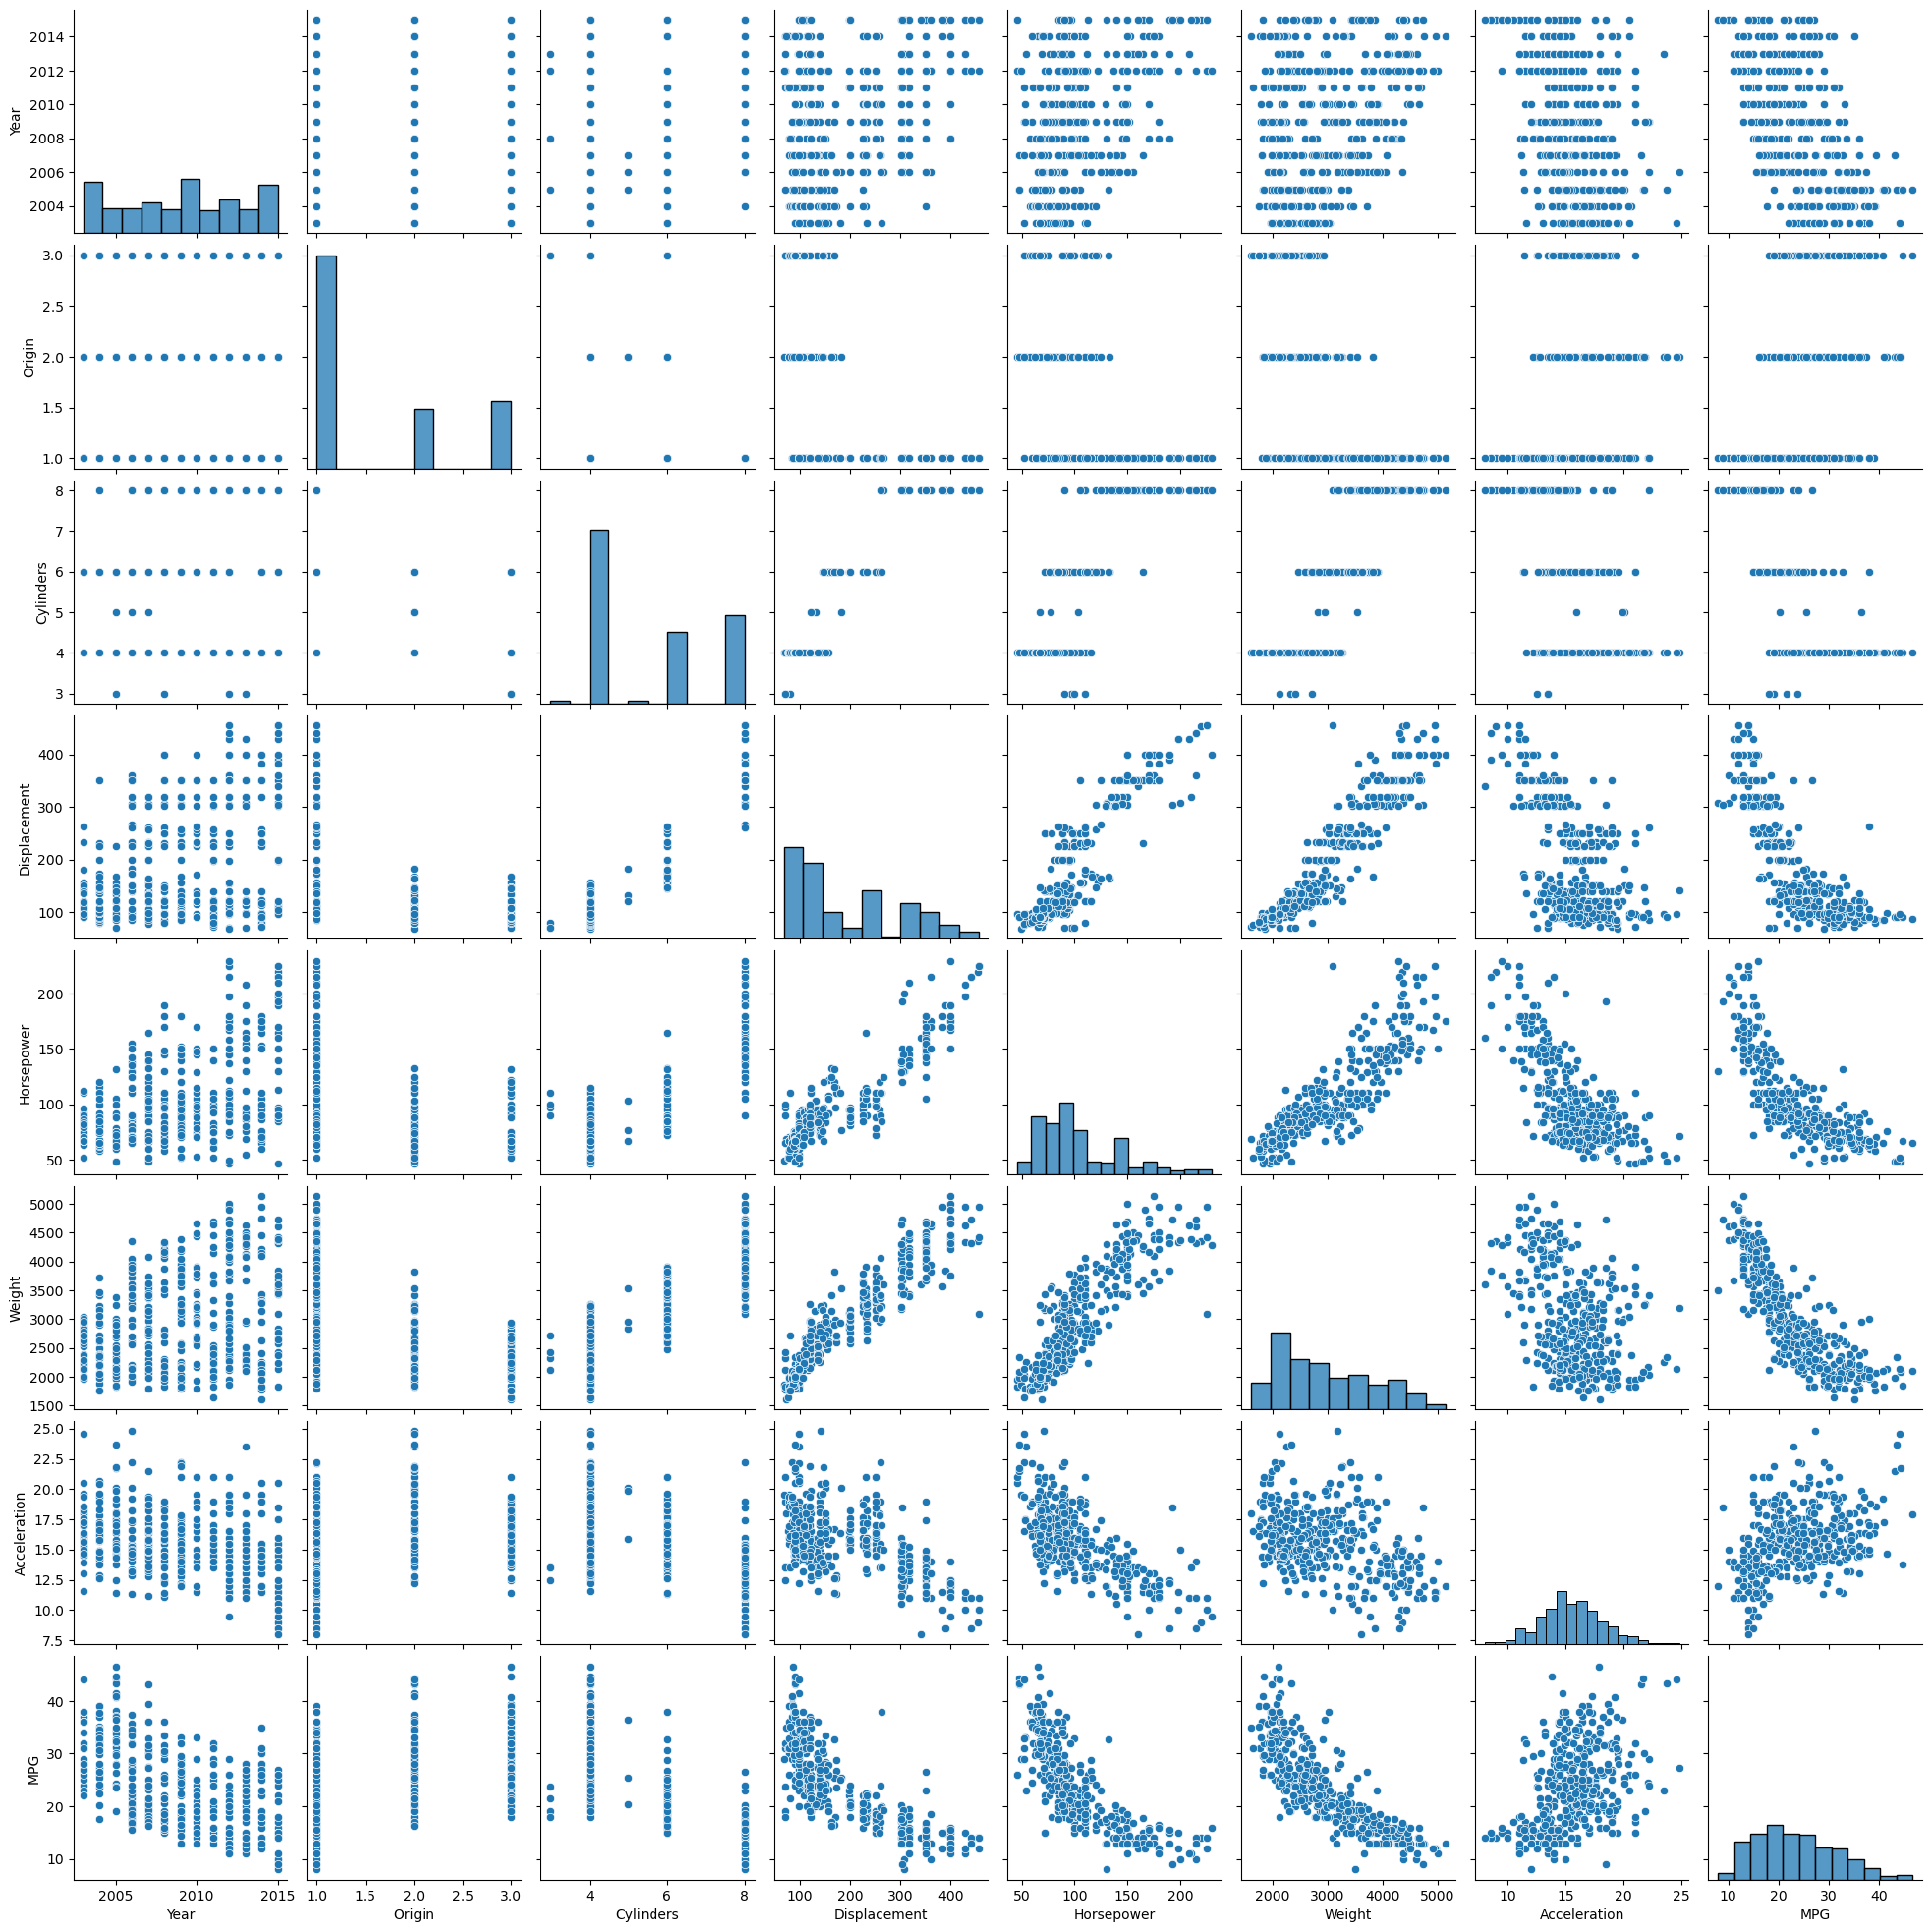

In [5]:
sns.pairplot(df)

In [6]:
df = df.dropna()

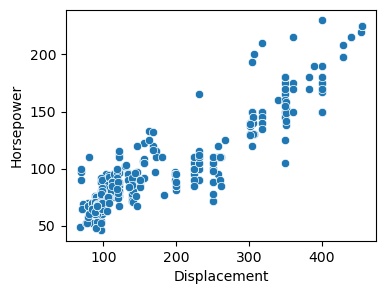

In [7]:
plt.figure(figsize = [4,3])
sns.scatterplot(data = df,x='Displacement',y='Horsepower')
plt.show()

In [8]:
from sklearn.cluster import KMeans

In [9]:
model = KMeans(n_clusters = 3) ###tell machine that devived in 3 groups

In [10]:
df2 = df[['Displacement','Horsepower']]
df2

,Displacement,Horsepower
0,307.0,130.0
1,350.0,165.0
2,318.0,150.0
3,304.0,150.0
4,302.0,140.0
...,...,...
393,140.0,86.0
394,97.0,52.0
395,135.0,84.0
396,120.0,79.0


In [11]:
model.fit(df2)

C:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [12]:
model.cluster_centers_

array([[110.28672986,  79.50236967],
       [349.25510204, 160.81632653],
       [225.44578313, 101.40963855]])

In [13]:
model.cluster_centers_[:,0]

array([110.28672986, 349.25510204, 225.44578313])

In [14]:
model.cluster_centers_[:,1]

array([ 79.50236967, 160.81632653, 101.40963855])

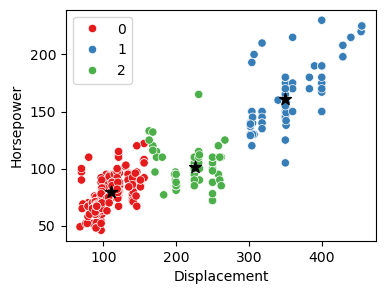

In [15]:
plt.figure(figsize=[4,3])
sns.scatterplot(data = df, x='Displacement', y='Horsepower', hue= model.labels_, palette='Set1')
plt.scatter(model.cluster_centers_[:,0], model.cluster_centers_[:,1], s=80, marker='*', c='k')
plt.show()

In [16]:
model.labels_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 2, 2, 2, 0, 0, 0, 0,
       0, 0, 2, 1, 1, 1, 1, 0, 0, 0, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1,
       2, 0, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 0, 1, 1, 1, 1, 2, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 2, 2, 2, 0, 0, 0, 0, 2,
       2, 2, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2,
       1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 1, 0, 0, 2, 0, 0, 0, 0, 2, 0, 2, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 2, 0, 0, 0, 0, 2,
       2, 2, 2, 0, 0, 0, 0, 0, 1, 0, 0, 2, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1,
       2, 1, 1, 2, 2, 2, 2, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 2, 1, 1, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 1, 2, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0, 0, 2, 2, 0, 2, 2, 1, 1, 1,
       1, 1, 1, 2, 1, 0, 0, 0, 0, 2, 1, 0, 2, 0, 0,

In [17]:
model.predict([[400,200]])

C:\Users\Asus\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


array([1], dtype=int32)

C:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


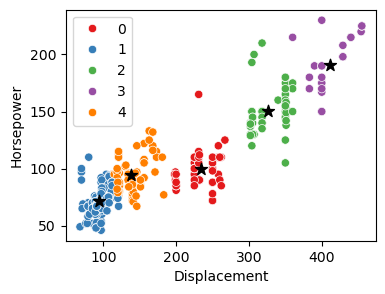

In [18]:
df2 = df[['Displacement','Horsepower']]
df2

from sklearn.cluster import KMeans
model = KMeans(n_clusters=5)
model.fit(df2)

plt.figure(figsize=[4,3])
sns.scatterplot(data = df, x='Displacement', y='Horsepower', hue= model.labels_, palette='Set1')
plt.scatter(model.cluster_centers_[:,0], model.cluster_centers_[:,1], s=80, marker='*', c='k')
plt.show()

C:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


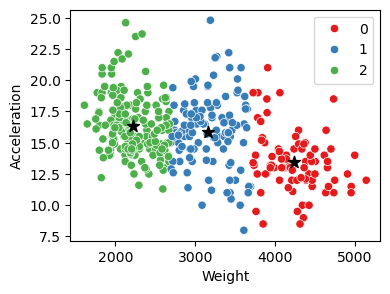

In [19]:
df2 = df[['Weight','Acceleration']]
df2

from sklearn.cluster import KMeans
model = KMeans(n_clusters=3)
model.fit(df2)

plt.figure(figsize=[4,3])
sns.scatterplot(data = df, x='Weight', y='Acceleration', hue= model.labels_, palette='Set1')
plt.scatter(model.cluster_centers_[:,0], model.cluster_centers_[:,1], s=80, marker='*', c='k')
plt.show()

In [20]:
df2 = df[['Weight','Acceleration']]
df2

,Weight,Acceleration
0,3504,12.0
1,3693,11.5
2,3436,11.0
3,3433,12.0
4,3449,10.5
...,...,...
393,2790,15.6
394,2130,24.6
395,2295,11.6
396,2625,18.6


In [21]:
from sklearn.preprocessing import StandardScaler

In [22]:
scaler = StandardScaler()
df2[['Weight','Acceleration']] = scaler.fit_transform(df2)

C:\Users\Asus\AppData\Local\Temp\ipykernel_8108\2976496729.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2[['Weight','Acceleration']] = scaler.fit_transform(df2)


C:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


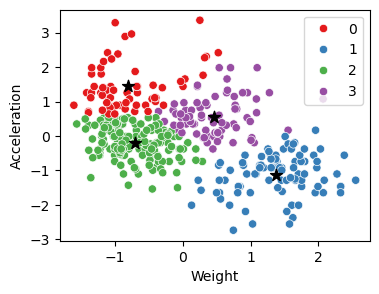

In [23]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters=4)
model.fit(df2)

plt.figure(figsize=[4,3])
sns.scatterplot(data = df2, x='Weight', y='Acceleration', hue= model.labels_, palette='Set1')
plt.scatter(model.cluster_centers_[:,0], model.cluster_centers_[:,1], s=80, marker='*', c='k')
plt.show()

C:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


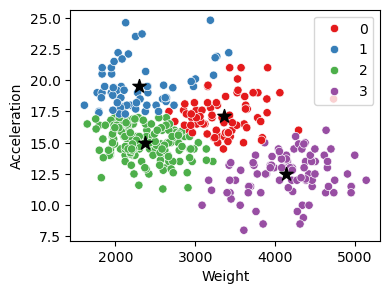

In [24]:
df2 = df2[['Weight','Acceleration']]
from sklearn.cluster import KMeans

model = KMeans(n_clusters=4)
model.fit(df2)

centers_real = scaler.inverse_transform(model.cluster_centers_)

df_real = pd.DataFrame(scaler.inverse_transform(df2),columns=['Weight','Acceleration'])

plt.figure(figsize=[4,3])
sns.scatterplot(data=df_real,x='Weight',y='Acceleration', hue=model.labels_,palette='Set1')
plt.scatter(centers_real[:,0],centers_real[:,1],s=100, marker='*', c='k')

plt.show()
